In [1]:
import ROOT
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
ROOT.ROOT.EnableImplicitMT()
ROOT.gStyle.SetPaintTextFormat('4.2f%%')
ROOT.gInterpreter.ProcessLine("using namespace ROOT::VecOps;")
ROOT.gInterpreter.ProcessLine("using namespace std;")

0

In [3]:
t = ROOT.TChain("thits","tree of hits")
for i in range(100):
# for i in range(50,100):
    if i in [13, 28, 32, 39, 40, 41, 52, 68, 70, 73, 77, 81, 85, 91, 93]:
        continue
    t.AddFile(f"files/hits/sand-spill-events.{i}.hits.root")
    break
df = ROOT.RDataFrame(t)
# df = df.Range(100000)

In [ ]:
ROOT.gInterpreter.ProcessLine("""
#include <mutex>
string get_geo_path(double x, double y, double z) {
    static mutex mtx;
    static TFile f("/storage/gpfs_data/neutrino/users/mt/ANA/spill_slicing/productions/SAND/SAND_0/sand-events.0.edep.root");
    static TGeoManager* g(f.Get<TGeoManager>("EDepSimGeometry"));
    mtx.lock();
    g->FindNode(x, y, z);
    auto s = string(g->GetPath());
    mtx.unlock();
    return s;
}
""")

0

In [ ]:
ROOT.gInterpreter.ProcessLine("""
string get_geo_node_name(string& s) {
    TString mys(s); 
    auto oa = mys.Tokenize("/"); 
    int idx = oa->GetEntries() >= 6 ? 5 : oa->GetEntries()-1; 
    return string(static_cast<TObjString*>(oa->At(idx))->GetString().Data());
}
""")

0

In [6]:
ROOT.gInterpreter.ProcessLine("""
string get_geo_element_name(string& s) {
    if (s.rfind("KLOESolenoid", 0) == 0) return string("MagnetSolenoid");
    if (s.rfind("KLOEYoke", 0) == 0) return string("MagnetYoke");
    if (s == "MagIntVol_volume_PV_0") return string("MagnetizedVolume");
    if (s == "kloe_calo_volume_PV_0") return string("Calorimeter");
    if (s == "sand_inner_volume_PV_0") return string("InnerVolume");
    if (s == "volSAND_PV_0") return string("Sand");
    return string("Unknown");
}
""")

0

In [7]:
ROOT.gInterpreter.ProcessLine("""
// if you remove 'std::' you will get "error: function definition is not allowed here"
std::pair<double, double> get_event_time_window(RVec<double>& hit_t, 
                                                RVec<double>& hit_e, 
                                                double sliding_time_window_energy_threshold, 
                                                double sliding_time_window_length = 10.) {
                                 
                                 
    auto event_time_window_begin = numeric_limits<double>::quiet_NaN();
    auto event_time_window_end = numeric_limits<double>::quiet_NaN();
    if (hit_t.size() == 0) return make_pair(event_time_window_begin, event_time_window_end);
    
    auto check_if_energy_in_sliding_window_is_above_threshold = [sliding_time_window_energy_threshold, &hit_t, &hit_e](double start, double stop){ return Sum(((hit_t > start) && (hit_t < stop)) * hit_e) > sliding_time_window_energy_threshold;};
    auto sliding_time_window_start = trunc(Min(hit_t));
    auto sliding_time_window_stop = sliding_time_window_start + sliding_time_window_length;
    auto max_sliding_time_window_start = min(trunc(Max(hit_t)) + 1., 20000.);
    
    // find the begin of the event
    auto is_energy_in_sliding_window_above_threshold = check_if_energy_in_sliding_window_is_above_threshold(sliding_time_window_start, sliding_time_window_stop);
    while (is_energy_in_sliding_window_above_threshold == false && sliding_time_window_start < max_sliding_time_window_start) {
        sliding_time_window_start += 1.;
        sliding_time_window_stop = sliding_time_window_start + sliding_time_window_length;
        is_energy_in_sliding_window_above_threshold = check_if_energy_in_sliding_window_is_above_threshold(sliding_time_window_start, sliding_time_window_stop);
    }
    if (is_energy_in_sliding_window_above_threshold == true) event_time_window_begin = sliding_time_window_start;
    else return make_pair(event_time_window_begin, event_time_window_end);
    
    // find the end of the event
    while (is_energy_in_sliding_window_above_threshold == true && sliding_time_window_start < max_sliding_time_window_start) {
        sliding_time_window_start += 1.;
        sliding_time_window_stop = sliding_time_window_start + sliding_time_window_length;
        is_energy_in_sliding_window_above_threshold = check_if_energy_in_sliding_window_is_above_threshold(sliding_time_window_start, sliding_time_window_stop);
    }
    event_time_window_end = sliding_time_window_stop;
    return make_pair(event_time_window_begin, event_time_window_end);
}
""")

0

In [8]:
ROOT.gInterpreter.ProcessLine("auto _fecal = [](RVec<string>& v){return Nonzero(v == \"EMCalSci\");};")
ROOT.gInterpreter.ProcessLine("auto _ftrck = [](RVec<string>& v){return Nonzero(v == \"DriftVolume\");};")

140445219438592

In [9]:
df = df.Define("evt_geo_path","get_geo_path(evt_x, evt_y, evt_z)")\
       .Define("evt_geo_node_name","get_geo_node_name(evt_geo_path);")\
       .Define("evt_geo_element_name","get_geo_element_name(evt_geo_node_name);")\
       .Define("evt_hits_n","hit_t.size()")\
       .Define("evt_hits_logn","log10(evt_hits_n)")\
       .Define("evt_hits_tmin","return evt_hits_n == 0u ? numeric_limits<double>::quiet_NaN() : Min(hit_t);")\
       .Define("evt_hits_tmax","return evt_hits_n == 0u ? numeric_limits<double>::quiet_NaN() : Max(hit_t);")\
       .Define("evt_hits_dt","evt_hits_tmax - evt_hits_tmin")\
       .Define("hit_t_corr","hit_t - hit_z / 300")\
       .Define("evt_hits_tmin_corr","return evt_hits_n == 0u ? numeric_limits<double>::quiet_NaN() : Min(hit_t_corr);")\
       .Define("evt_hits_tmax_corr","return evt_hits_n == 0u ? numeric_limits<double>::quiet_NaN() : Max(hit_t_corr);")\
       .Define("evt_hits_dt_corr","evt_hits_tmax_corr - evt_hits_tmin_corr")\
       .Define("evt_hits_log_dt","log10(evt_hits_dt)")\
       .Define("evt_hits_log_dt_corr","log10(evt_hits_dt_corr)")\
       .Define("evt_hits_sum_de","return evt_hits_n == 0u ? 0. : Sum(hit_de);")\
       .Define("hit_ecal_id","return _fecal(hit_det)")\
       .Define("evt_hits_ecal_n","hit_ecal_id.size()")\
       .Define("hit_ecal_x","Take(hit_x,hit_ecal_id)")\
       .Define("hit_ecal_y","Take(hit_y,hit_ecal_id)")\
       .Define("hit_ecal_z","Take(hit_z,hit_ecal_id)")\
       .Define("hit_ecal_t","Take(hit_t,hit_ecal_id)")\
       .Define("hit_ecal_de","Take(hit_de,hit_ecal_id)")\
       .Define("hit_ecal_pdg","Take(hit_pdg,hit_ecal_id)")\
       .Define("evt_hits_ecal_tmin","return evt_hits_ecal_n == 0u ? numeric_limits<double>::quiet_NaN() : Min(hit_ecal_t);")\
       .Define("evt_hits_ecal_tmax","return evt_hits_ecal_n == 0u ? numeric_limits<double>::quiet_NaN() : Max(hit_ecal_t);")\
       .Define("evt_hits_ecal_dt","evt_hits_ecal_tmax - evt_hits_ecal_tmin")\
       .Define("hit_ecal_t_corr","hit_ecal_t - hit_ecal_z / 300")\
       .Define("evt_hits_ecal_tmin_corr","return evt_hits_ecal_n == 0u ? numeric_limits<double>::quiet_NaN() : Min(hit_ecal_t_corr);")\
       .Define("evt_hits_ecal_tmax_corr","return evt_hits_ecal_n == 0u ? numeric_limits<double>::quiet_NaN() : Max(hit_ecal_t_corr);")\
       .Define("evt_hits_ecal_dt_corr","evt_hits_ecal_tmax_corr - evt_hits_ecal_tmin_corr")\
       .Define("evt_hits_ecal_sum_e","Sum(hit_ecal_de)")\
       .Define("hit_trck_id","return _ftrck(hit_det)")\
       .Define("evt_hits_trck_n","hit_trck_id.size()")\
       .Define("hit_trck_x","Take(hit_x,hit_trck_id)")\
       .Define("hit_trck_y","Take(hit_y,hit_trck_id)")\
       .Define("hit_trck_z","Take(hit_z,hit_trck_id)")\
       .Define("hit_trck_t","Take(hit_t,hit_trck_id)")\
       .Define("hit_trck_de","Take(hit_de,hit_trck_id)")\
       .Define("hit_trck_pdg","Take(hit_pdg,hit_trck_id)")\
       .Define("evt_hits_trck_tmin","return evt_hits_trck_n == 0u ? numeric_limits<double>::quiet_NaN() : Min(hit_trck_t);")\
       .Define("evt_hits_trck_tmax","return evt_hits_trck_n == 0u ? numeric_limits<double>::quiet_NaN() : Max(hit_trck_t);")\
       .Define("evt_hits_trck_dt","evt_hits_trck_tmax - evt_hits_trck_tmin")\
       .Define("hit_trck_t_corr","hit_trck_t - hit_trck_z / 300")\
       .Define("evt_hits_trck_tmin_corr","return evt_hits_trck_n == 0u ? numeric_limits<double>::quiet_NaN() : Min(hit_trck_t_corr);")\
       .Define("evt_hits_trck_tmax_corr","return evt_hits_trck_n == 0u ? numeric_limits<double>::quiet_NaN() : Max(hit_trck_t_corr);")\
       .Define("evt_hits_trck_dt_corr","evt_hits_trck_tmax_corr - evt_hits_trck_tmin_corr")\
       .Define("evt_hits_trck_sum_e","Sum(hit_trck_de)")\
       .Define("evt_hits_ecal_time_window","get_event_time_window(hit_ecal_t, hit_ecal_de, 5.)")\
       .Define("evt_hits_ecal_time_window_start","evt_hits_ecal_time_window.first")\
       .Define("evt_hits_ecal_time_window_stop","evt_hits_ecal_time_window.second")\
       .Define("evt_hits_ecal_time_window_length","evt_hits_ecal_time_window_stop-evt_hits_ecal_time_window_start")\
       .Define("evt_hits_ecal_n_in_time_window","Sum((hit_ecal_t > evt_hits_ecal_time_window_start) && (evt_hits_ecal_time_window_start < evt_hits_ecal_time_window_stop))")\
       .Define("evt_hits_ecal_de_in_time_window","Sum(hit_ecal_de * ((hit_ecal_t > evt_hits_ecal_time_window_start) && (evt_hits_ecal_time_window_start < evt_hits_ecal_time_window_stop)))")\
       .Define("evt_hits_ecal_frac_n_in_time_window","evt_hits_ecal_n == 0. ? numeric_limits<double>::quiet_NaN() : evt_hits_ecal_n_in_time_window/evt_hits_ecal_n")\
       .Define("evt_hits_ecal_frac_de_in_time_window","evt_hits_ecal_sum_e == 0. ? numeric_limits<double>::quiet_NaN() : evt_hits_ecal_de_in_time_window/evt_hits_ecal_sum_e")\
       .Define("evt_hits_trck_time_window","get_event_time_window(hit_trck_t, hit_trck_de, 0.005)")\
       .Define("evt_hits_trck_time_window_start","evt_hits_trck_time_window.first")\
       .Define("evt_hits_trck_time_window_stop","evt_hits_trck_time_window.second")\
       .Define("evt_hits_trck_time_window_length","evt_hits_trck_time_window_stop-evt_hits_trck_time_window_start")\
       .Define("evt_hits_trck_n_in_time_window","Sum((hit_trck_t > evt_hits_trck_time_window_start) && (evt_hits_trck_time_window_start < evt_hits_trck_time_window_stop))")\
       .Define("evt_hits_trck_de_in_time_window","Sum(hit_trck_de * ((hit_trck_t > evt_hits_trck_time_window_start) && (evt_hits_trck_time_window_start < evt_hits_trck_time_window_stop)))")\
       .Define("evt_hits_trck_frac_n_in_time_window","evt_hits_trck_n == 0. ? numeric_limits<double>::quiet_NaN() : evt_hits_trck_n_in_time_window/evt_hits_trck_n")\
       .Define("evt_hits_trck_frac_de_in_time_window","evt_hits_trck_sum_e == 0. ? numeric_limits<double>::quiet_NaN() : evt_hits_trck_de_in_time_window/evt_hits_trck_sum_e")

In [10]:
h_evt_t = df.Histo1D(("h_evt_t",";interaction time (ns)",1200,-1000,11000),"evt_t")
h_hits_t = df.Histo1D(("h_hits_t","; hit time (ns)",2000,-1000,19000),"hit_t")
h_hits_log_dt = df.Histo1D(("h_hits_log_dt","; log10(hit time range in event/1ns)",100,-5,7),"evt_hits_log_dt")
h_hits_log_dt_corr = df.Histo1D(("h_hits_log_dt_corr","; log10(hit cTOF-corrected time range in event/1ns)",100,-5,7),"evt_hits_log_dt_corr")
h_hits_t_vs_evt_t = df.Histo2D(("h_hits_t_vs_evt_t","; interaction time (ns); hit time (ns)",120,0,12000,200,0,20000),"evt_t","evt_hits_dt")
h_hits_logn_vs_evt_t = df.Histo2D(("h_hits_logn_vs_evt_t","; interaction time (ns); log10(number of hits)",120,0,12000,100,0,5),"evt_t","evt_hits_logn")
h_evt_zy = df.Histo2D(("h_evt_zy","; interaction Z (mm); interaction Y (mm)",100,20000,28000,100,-6000,1000),"evt_z","evt_y")
h_evt_zx = df.Histo2D(("h_evt_zx","; interaction Z (mm); interaction X (mm)",100,20000,28000,100,-4000,4000),"evt_z","evt_x")
h_hits_ecal_sum_e = df.Histo1D(("h_hits_ecal_sum_e","; sum of ECAL hit energy (MeV)",100000,0,100),"evt_hits_ecal_sum_e")
h_hit_ecal_log10_de = df.Define("hit_ecal_log10_de","log10(hit_ecal_de)").Histo1D(("h_hit_ecal_log10_de","; log10(hit energy/MeV)",10000,-12,3),"hit_ecal_log10_de")
h_hits_trck_sum_e = df.Histo1D(("h_hits_trck_sum_e","; sum of TRACKER hit energy (MeV)",100000,0,100),"evt_hits_trck_sum_e")
h_hit_trck_log10_de = df.Define("hit_trck_log10_de","log10(hit_trck_de)").Histo1D(("h_hit_trck_log10_de","; log10(hit energy/MeV)",10000,-12,3),"hit_trck_log10_de")

In [11]:
ethrld = [0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
volnames = ["MagnetSolenoid", "MagnetYoke", "Calorimeter", "InnerVolume", "Sand", "MagnetizedVolume", "Unknown"]
twndw = [5, 10, 20, 50]
evt_n = df.Count()
df_evts_in_ecal = df.Filter("evt_geo_element_name==\"Calorimeter\"")
df_evts_in_invol = df.Filter("evt_geo_element_name==\"InnerVolume\"")
evt_in_ecal_n = df_evts_in_ecal.Count()
evt_in_invol_n = df_evts_in_invol.Count()
evt_n_hits_ecal_sum_e_gt_0 = df_evts_in_ecal.Filter("evt_hits_ecal_sum_e>0").Count()
evt_n_hits_trck_sum_e_gt_0 = df_evts_in_invol.Filter("evt_hits_trck_sum_e>0").Count()
evt_geo_element_name_counts = [(ix, el, df.Filter(f"evt_geo_element_name==\"{el}\"").Count()) for ix, el in enumerate(volnames)]
h_hits_ecal_log10_n = df_evts_in_ecal.Define("evt_hits_ecal_log10_n","log10(evt_hits_ecal_n)").Histo1D(("h_hits_ecal_log10_n","; log10(number of hits)",100,-1,6),"evt_hits_ecal_log10_n")
h_hits_trck_log10_n = df_evts_in_invol.Define("evt_hits_trck_log10_n","log10(evt_hits_trck_n)").Histo1D(("h_hits_trck_log10_n","; log10(number of hits)",100,-1,6),"evt_hits_trck_log10_n")

In [12]:
evt_hits_ecal_sum_e_w_ecuts = {en: df_evts_in_ecal.Filter(f"evt_hits_ecal_sum_e>{en}").Count() for en in ethrld}
evt_hits_trck_sum_e_w_ecuts = {en: df_evts_in_invol.Filter(f"evt_hits_trck_sum_e>{en}").Count() for en in ethrld}
evt_hits_ecal_sum_e_w_tcuts_and_ecuts = {} 
evt_hits_trck_sum_e_w_tcuts_and_ecuts = {} 
for tw in twndw:
    evt_hits_ecal_sum_e_w_tcuts_and_ecuts[tw] = {en: df_evts_in_ecal\
        .Define(f"evt_hits_ecal_sum_e_{tw}ns",f"Sum(((hit_ecal_t - evt_hits_ecal_tmin) < {tw}) * hit_ecal_de)")\
        .Filter(f"evt_hits_ecal_sum_e_{tw}ns>{en}").Count() for en in ethrld}
    evt_hits_trck_sum_e_w_tcuts_and_ecuts[tw] = {en: df_evts_in_invol\
        .Define(f"evt_hits_trck_sum_e_{tw}ns",f"Sum(((hit_trck_t - evt_hits_trck_tmin) < {tw}) * hit_trck_de)")\
        .Filter(f"evt_hits_trck_sum_e_{tw}ns>{en}").Count() for en in ethrld}

In [13]:
h_evt_hits_ecal_time_window_length = df_evts_in_ecal.Histo1D(("h_evt_hits_ecal_time_window_length","",200,0,200),"evt_hits_ecal_time_window_length")
h_evt_hits_trck_time_window_length = df_evts_in_invol.Histo1D(("h_evt_hits_trck_time_window_length","",200,0,200),"evt_hits_trck_time_window_length")
h_evt_hits_ecal_frac_n_in_time_window = df_evts_in_ecal.Histo1D(("h_evt_hits_ecal_frac_n_in_time_window","",110,0,1.1),"evt_hits_ecal_frac_n_in_time_window")
h_evt_hits_ecal_frac_de_in_time_window = df_evts_in_ecal.Histo1D(("h_evt_hits_ecal_frac_de_in_time_window","",110,0,1.1),"evt_hits_ecal_frac_de_in_time_window")
h_evt_hits_trck_frac_n_in_time_window = df_evts_in_invol.Histo1D(("h_evt_hits_trck_frac_n_in_time_window","",110,0,1.1),"evt_hits_trck_frac_n_in_time_window")
h_evt_hits_trck_frac_de_in_time_window = df_evts_in_invol.Histo1D(("h_evt_hits_trck_frac_de_in_time_window","",110,0,1.1),"evt_hits_trck_frac_de_in_time_window")

complete_events_in_ecal = df_evts_in_ecal.Filter("evt_hits_ecal_frac_de_in_time_window == 1.").Count()
total_events_in_ecal = df_evts_in_ecal.Filter("evt_hits_ecal_sum_e > 0.").Count()
complete_events_in_invol = df_evts_in_ecal.Filter("evt_hits_trck_frac_de_in_time_window==1.").Count()
total_events_in_invol = df_evts_in_ecal.Filter("evt_hits_trck_sum_e > 0.").Count()

In [14]:
sp_id = 557
ev_id = 28
tw_step = 20.
n_step = 5
df_this_event_tw_slicing = {i_step: df_evts_in_ecal.Filter(f"spl_id == {sp_id} && evt_id == {ev_id}")\
                                                   .Define("selected_hit_indices",f"Nonzero((hit_ecal_t > evt_hits_ecal_time_window_start + {i_step*tw_step}) && (hit_ecal_t < evt_hits_ecal_time_window_start + {(i_step+1)*tw_step}))")\
                                                   .Define("selected_hit_x","Take(hit_ecal_x, selected_hit_indices)")\
                                                   .Define("selected_hit_y","Take(hit_ecal_y, selected_hit_indices)")\
                                                   .Define("selected_hit_z","Take(hit_ecal_z, selected_hit_indices)")\
                                                   .Define("selected_hit_t","Take(hit_ecal_t, selected_hit_indices)")\
                                                   for i_step in range(n_step)}

gr_this_event_tw_slicing_yz = {i_step: df_step.Histo2D(("","",1000, 20000, 28000, 1000, -6000, 1000),"selected_hit_z","selected_hit_y") for i_step, df_step in df_this_event_tw_slicing.items()}
gr_this_event_tw_slicing_xz = {i_step: df_step.Histo2D(("","",1000, 20000, 28000, 1000, -3000, 3000),"selected_hit_z","selected_hit_x") for i_step, df_step in df_this_event_tw_slicing.items()}

In [15]:
myhits = df.AsNumpy(columns=["spl_id",
                             "evt_id",
                             "evt_geo_element_name",
                             "hit_ecal_t",
                             "hit_ecal_de",
                             "hit_trck_t",
                             "hit_trck_de",
                             "evt_hits_ecal_time_window_start",
                             "evt_hits_ecal_time_window_stop",
                             "evt_hits_trck_time_window_start",
                             "evt_hits_trck_time_window_stop"])

Warning in <TClass::Init>: no dictionary for class TG4Event is available
Warning in <TClass::Init>: no dictionary for class TG4PrimaryVertex is available
Warning in <TClass::Init>: no dictionary for class TG4Trajectory is available
Warning in <TClass::Init>: no dictionary for class pair<string,vector<TG4HitSegment> > is available
Warning in <TClass::Init>: no dictionary for class TG4PrimaryParticle is available
Warning in <TClass::Init>: no dictionary for class TG4TrajectoryPoint is available
Warning in <TClass::Init>: no dictionary for class TG4HitSegment is available
Info in <TGeoManager::CloseGeometry>: Geometry loaded from file...
Info in <TGeoManager::SetTopVolume>: Top volume is volWorld_PV. Master volume is volWorld_PV
Info in <TGeoNavigator::BuildCache>: --- Maximum geometry depth set to 100
Info in <TGeoManager::Voxelize>: Voxelizing...
Info in <TGeoManager::CountLevels>: max level = 23, max placements = 418
Info in <TGeoManager::CloseGeometry>: 201401 nodes/ 5544 volume UID's

In [16]:
# for col in ["hit_ecal_t", "hit_ecal_de", "hit_trck_t", "hit_ecal_t"]:
#     myhits[col] = np.array([np.asarray(v) for v in myhits[col]])

In [17]:
# myhits = df.AsNumpy(columns=["spl_id",
#                              "evt_id",
#                              "evt_x",
#                              "evt_y",
#                              "evt_z",
#                              "evt_t",
#                              "evt_geo_element_name",
#                              "hit_ecal_x",
#                              "hit_ecal_y",
#                              "hit_ecal_z",
#                              "hit_ecal_t",
#                              "hit_ecal_de",
#                              "hit_ecal_pdg",
#                              "hit_trck_x",
#                              "hit_trck_y",
#                              "hit_trck_z",
#                              "hit_trck_t",
#                              "hit_trck_de",
#                              "hit_trck_pdg",
#                              "evt_hits_ecal_time_window_start",
#                              "evt_hits_ecal_time_window_stop",
#                              "evt_hits_trck_time_window_start",
#                              "evt_hits_trck_time_window_stop"])

In [18]:
df_hits = pd.DataFrame(myhits)
df_hits["hit_ecal_evt_id"] = df_hits.apply(lambda row: [row["evt_id"]] * len(row["hit_ecal_t"]), axis = 1)
df_hits["hit_trck_evt_id"] = df_hits.apply(lambda row: [row["evt_id"]] * len(row["hit_trck_t"]), axis = 1)

In [19]:
df_grp = df_hits.groupby(by="spl_id").agg({"evt_id": lambda x: list(x),
                                            "evt_geo_element_name": lambda x: [''.join(s) for s in x],
                                            "evt_hits_ecal_time_window_start": lambda x: list(x),
                                            "evt_hits_ecal_time_window_stop": lambda x: list(x),
                                            "evt_hits_trck_time_window_start": lambda x: list(x),
                                            "evt_hits_trck_time_window_stop": lambda x: list(x),
                                            "hit_ecal_evt_id": "sum",
                                            "hit_ecal_t": lambda x: list(np.concatenate(x.values)),
                                            "hit_ecal_de": lambda x: list(np.concatenate(x.values)),
                                            "hit_trck_evt_id": "sum",
                                            "hit_trck_t": lambda x: list(np.concatenate(x.values)),
                                            "hit_trck_de": lambda x: list(np.concatenate(x.values)),
                                            }).reset_index()

In [20]:
df_grp.head(1)

,spl_id,evt_id,evt_geo_element_name,evt_hits_ecal_time_window_start,evt_hits_ecal_time_window_stop,evt_hits_trck_time_window_start,evt_hits_trck_time_window_stop,hit_ecal_evt_id,hit_ecal_t,hit_ecal_de,hit_trck_evt_id,hit_trck_t,hit_trck_de
0,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[MagnetYoke, MagnetYoke, MagnetYoke, MagnetYok...","[nan, 130.0, 151.0, 264.0, nan, nan, nan, 527....","[nan, 142.0, 173.0, 276.0, nan, nan, nan, 538....","[nan, 134.0, 468.0, 268.0, nan, nan, nan, nan,...","[nan, 152.0, 480.0, 286.0, nan, nan, nan, nan,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3292.3202408510565, 3322.6445246841176, 3323....","[0.0007235576631501317, 0.0006219864008016884,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[134.23362792237089, 134.26982653396573, 134.3...","[0.0006959250313229859, 0.002977158408612013, ..."


In [21]:
for col in ["evt_id",
            "evt_hits_ecal_time_window_start",
            "evt_hits_ecal_time_window_stop",
            "evt_hits_trck_time_window_start",
            "evt_hits_trck_time_window_stop",
            "hit_ecal_evt_id",
            "hit_ecal_t",
            "hit_ecal_de",
            "hit_trck_evt_id",
            "hit_trck_t",
            "hit_trck_de"]:
    df_grp[col] = df_grp[col].apply(lambda v: np.array(v))

In [23]:
# df_grp["hit_ecal_in_time_n_sig"] = df_grp.apply(lambda row: [len(np.nonzero(np.logical_and(np.logical_and(row["hit_ecal_t"] > start, row["hit_ecal_t"] < stop), row["hit_ecal_evt_id"] == e_id))[0] for start, stop, e_id in zip(row["evt_hits_ecal_time_window_start"], row["evt_hits_ecal_time_window_stop"], row["evt_id"])], axis = 1)

In [24]:
df_grp["evt_spl_id"] = df_grp.apply(lambda row: np.array([row["spl_id"] for _ in row["evt_id"]]), axis = 1)
df_grp["hit_ecal_n_sig"] = df_grp.apply(lambda row: [len(np.nonzero(e_id == row["hit_ecal_evt_id"])[0]) for e_id in row["evt_id"]], axis = 1)
df_grp["hit_ecal_de_sig"] = df_grp.apply(lambda row: [np.sum(row["hit_ecal_de"][np.nonzero(e_id == row["hit_ecal_evt_id"])[0]]) for e_id in row["evt_id"]], axis = 1)
df_grp["hit_trck_n_sig"] = df_grp.apply(lambda row: [len(np.nonzero(e_id == row["hit_trck_evt_id"])[0]) for e_id in row["evt_id"]], axis = 1)
df_grp["hit_trck_de_sig"] = df_grp.apply(lambda row: [np.sum(row["hit_trck_de"][np.nonzero(e_id == row["hit_trck_evt_id"])[0]]) for e_id in row["evt_id"]], axis = 1)
df_grp["hit_ecal_in_time_n"] = df_grp.apply(lambda row: [len(np.nonzero(np.logical_and(row["hit_ecal_t"] > start, row["hit_ecal_t"] < stop))[0]) for start, stop in zip(row["evt_hits_ecal_time_window_start"], row["evt_hits_ecal_time_window_stop"])], axis = 1)
df_grp["hit_ecal_in_time_de"] = df_grp.apply(lambda row: [np.sum(row["hit_ecal_de"][np.nonzero(np.logical_and(row["hit_ecal_t"] > start, row["hit_ecal_t"] < stop))[0]]) for start, stop in zip(row["evt_hits_ecal_time_window_start"], row["evt_hits_ecal_time_window_stop"])], axis = 1)
df_grp["hit_trck_in_time_n"] = df_grp.apply(lambda row: [len(np.nonzero(np.logical_and(row["hit_trck_t"] > start, row["hit_trck_t"] < stop))[0]) for start, stop in zip(row["evt_hits_trck_time_window_start"], row["evt_hits_trck_time_window_stop"])], axis = 1)
df_grp["hit_trck_in_time_de"] = df_grp.apply(lambda row: [np.sum(row["hit_trck_de"][np.nonzero(np.logical_and(row["hit_trck_t"] > start, row["hit_trck_t"] < stop))[0]]) for start, stop in zip(row["evt_hits_trck_time_window_start"], row["evt_hits_trck_time_window_stop"])], axis = 1)
df_grp["hit_ecal_in_time_n_sig"] = df_grp.apply(lambda row: [len(np.nonzero(np.logical_and(np.logical_and(row["hit_ecal_t"] > start, row["hit_ecal_t"] < stop), row["hit_ecal_evt_id"] == e_id))[0]) for start, stop, e_id in zip(row["evt_hits_ecal_time_window_start"], row["evt_hits_ecal_time_window_stop"], row["evt_id"])], axis = 1)
df_grp["hit_ecal_in_time_de_sig"] = df_grp.apply(lambda row: [np.sum(row["hit_ecal_de"][np.nonzero(np.logical_and(np.logical_and(row["hit_ecal_t"] > start, row["hit_ecal_t"] < stop), row["hit_ecal_evt_id"] == e_id))[0]]) for start, stop, e_id in zip(row["evt_hits_ecal_time_window_start"], row["evt_hits_ecal_time_window_stop"], row["evt_id"])], axis = 1)
df_grp["hit_trck_in_time_n_sig"] = df_grp.apply(lambda row: [len(np.nonzero(np.logical_and(np.logical_and(row["hit_trck_t"] > start, row["hit_trck_t"] < stop), row["hit_trck_evt_id"] == e_id))[0]) for start, stop, e_id in zip(row["evt_hits_trck_time_window_start"], row["evt_hits_trck_time_window_stop"], row["evt_id"])], axis = 1)
df_grp["hit_trck_in_time_de_sig"] = df_grp.apply(lambda row: [np.sum(row["hit_trck_de"][np.nonzero(np.logical_and(np.logical_and(row["hit_trck_t"] > start, row["hit_trck_t"] < stop), row["hit_trck_evt_id"] == e_id))[0]]) for start, stop, e_id in zip(row["evt_hits_trck_time_window_start"], row["evt_hits_trck_time_window_stop"], row["evt_id"])], axis = 1)

In [25]:
df_evt = pd.DataFrame({c: np.concatenate(df_grp[c].array) for c in ["evt_spl_id",
                                                                    "evt_id",
                                                                    "evt_geo_element_name",
                                                                    "evt_hits_ecal_time_window_start",
                                                                    "evt_hits_ecal_time_window_stop",
                                                                    "evt_hits_trck_time_window_start",
                                                                    "evt_hits_trck_time_window_stop",
                                                                    "hit_ecal_n_sig",
                                                                    "hit_trck_n_sig",
                                                                    "hit_ecal_de_sig",
                                                                    "hit_trck_de_sig",
                                                                    "hit_ecal_in_time_n",
                                                                    "hit_trck_in_time_n",
                                                                    "hit_ecal_in_time_de",
                                                                    "hit_trck_in_time_de",
                                                                    "hit_ecal_in_time_n_sig",
                                                                    "hit_trck_in_time_n_sig",
                                                                    "hit_ecal_in_time_de_sig",
                                                                    "hit_trck_in_time_de_sig"]})


In [26]:
df_evt["hit_ecal_in_time_n_pur"] = df_evt["hit_ecal_in_time_n_sig"] / df_evt["hit_ecal_in_time_n"]
df_evt["hit_trck_in_time_n_pur"] = df_evt["hit_trck_in_time_n_sig"] / df_evt["hit_trck_in_time_n"]
df_evt["hit_ecal_in_time_de_pur"] = df_evt["hit_ecal_in_time_de_sig"] / df_evt["hit_ecal_in_time_de"]
df_evt["hit_trck_in_time_de_pur"] = df_evt["hit_trck_in_time_de_sig"] / df_evt["hit_trck_in_time_de"]
df_evt["hit_ecal_in_time_n_eff"] = df_evt["hit_ecal_in_time_n_sig"] / df_evt["hit_ecal_n_sig"]
df_evt["hit_trck_in_time_n_eff"] = df_evt["hit_trck_in_time_n_sig"] / df_evt["hit_trck_n_sig"]
df_evt["hit_ecal_in_time_de_eff"] = df_evt["hit_ecal_in_time_de_sig"] / df_evt["hit_ecal_de_sig"]
df_evt["hit_trck_in_time_de_eff"] = df_evt["hit_trck_in_time_de_sig"] / df_evt["hit_trck_de_sig"]

In [27]:
df_evt.head(2)

,evt_spl_id,evt_id,evt_geo_element_name,evt_hits_ecal_time_window_start,evt_hits_ecal_time_window_stop,evt_hits_trck_time_window_start,evt_hits_trck_time_window_stop,hit_ecal_n_sig,hit_trck_n_sig,hit_ecal_de_sig,...,hit_ecal_in_time_de_sig,hit_trck_in_time_de_sig,hit_ecal_in_time_n_pur,hit_trck_in_time_n_pur,hit_ecal_in_time_de_pur,hit_trck_in_time_de_pur,hit_ecal_in_time_n_eff,hit_trck_in_time_n_eff,hit_ecal_in_time_de_eff,hit_trck_in_time_de_eff
0,0,0,MagnetYoke,NaN,NaN,NaN,NaN,207,0,2.482866,...,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,0.00000,NaN
1,0,1,MagnetYoke,130.0,142.0,134.0,152.0,549,32,72.324992,...,36.635467,0.057622,1.0,1.0,1.0,1.0,0.431694,1.0,0.50654,1.0


In [28]:
df_ecal_evt = df_evt[df_evt["evt_geo_element_name"] == "Calorimeter"]
df_invol_evt = df_evt[df_evt["evt_geo_element_name"] == "InnerVolume"]

In [29]:
df_ecal_evt.head(2)

,evt_spl_id,evt_id,evt_geo_element_name,evt_hits_ecal_time_window_start,evt_hits_ecal_time_window_stop,evt_hits_trck_time_window_start,evt_hits_trck_time_window_stop,hit_ecal_n_sig,hit_trck_n_sig,hit_ecal_de_sig,...,hit_ecal_in_time_de_sig,hit_trck_in_time_de_sig,hit_ecal_in_time_n_pur,hit_trck_in_time_n_pur,hit_ecal_in_time_de_pur,hit_trck_in_time_de_pur,hit_ecal_in_time_n_eff,hit_trck_in_time_n_eff,hit_ecal_in_time_de_eff,hit_trck_in_time_de_eff
34,0,34,Calorimeter,3778.0,3795.0,NaN,NaN,541,0,237.016362,...,231.490399,0.0,0.994186,NaN,1.0000,NaN,0.948244,NaN,0.976685,NaN
40,0,40,Calorimeter,4426.0,4452.0,NaN,NaN,1142,0,349.801839,...,340.761710,0.0,0.956897,NaN,0.9932,NaN,0.583187,NaN,0.974156,NaN


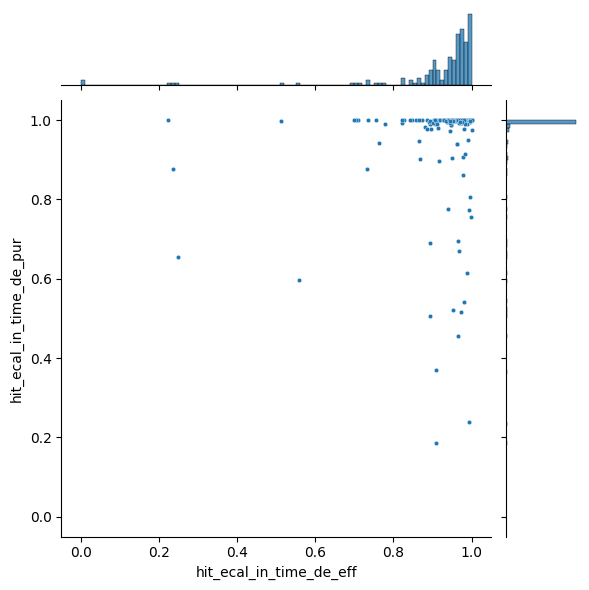

In [30]:
sns.jointplot(data=df_ecal_evt, x="hit_ecal_in_time_de_eff", 
                                y="hit_ecal_in_time_de_pur", 
                                kind = "scatter",
                                s = 10,
                                marginal_kws=dict(bins=np.linspace(0,1,101)))

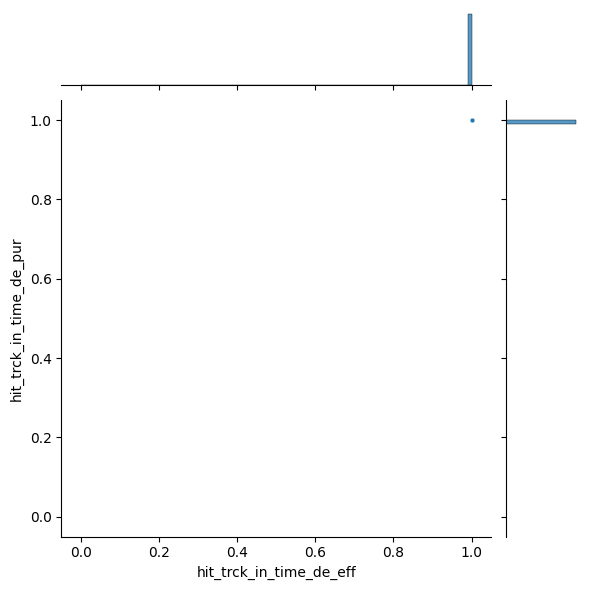

In [31]:
sns.jointplot(data=df_invol_evt, x="hit_trck_in_time_de_eff", 
                                y="hit_trck_in_time_de_pur", 
                                kind = "scatter",
                                s = 10,
                                marginal_kws=dict(bins=np.linspace(0,1,101)))

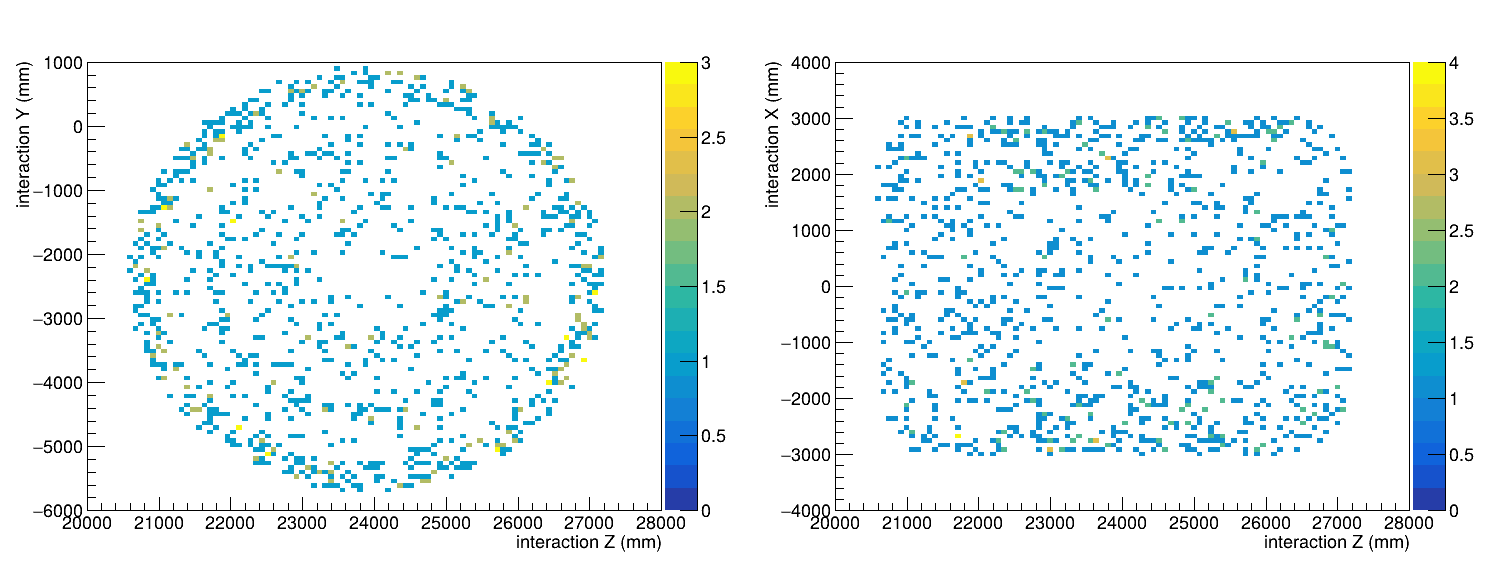

In [32]:
h_evt_zy.SetStats(False)
h_evt_zx.SetStats(False)
c = ROOT.TCanvas("","",1500,600)
c.Divide(2,1)
c.cd(1)
h_evt_zy.Draw("colz")
h_evt_zy.GetYaxis().SetTitleOffset(1.55)
c.cd(2)
h_evt_zx.Draw("colz")
h_evt_zx.GetYaxis().SetTitleOffset(1.55)
c.Draw()

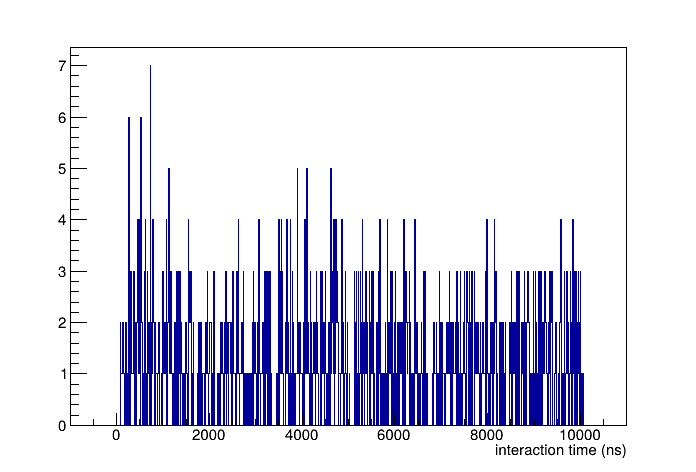

In [33]:
h_evt_t.SetStats(False)
c = ROOT.TCanvas()
h_evt_t.Draw()
c.Draw()

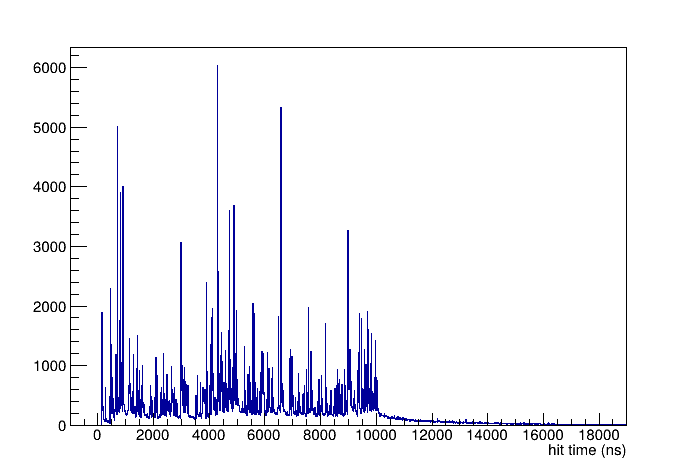

In [34]:
h_hits_t.SetStats(False)
c = ROOT.TCanvas()
h_hits_t.Draw()
c.Draw()

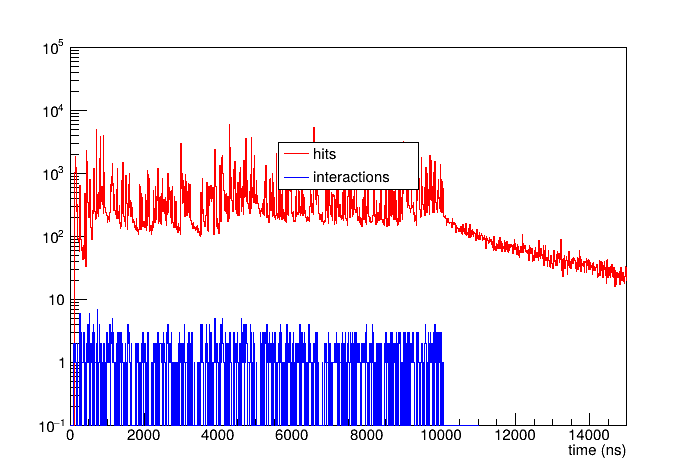

In [35]:
leg = ROOT.TLegend(0.4,0.6,0.6,0.7)
leg.AddEntry(h_hits_t.GetPtr(), "hits", "l")
leg.AddEntry(h_evt_t.GetPtr(), "interactions", "l")

c = ROOT.TCanvas()
h_hits_t.SetLineColor(ROOT.kRed)
h_evt_t.SetLineColor(ROOT.kBlue)
c.DrawFrame(0,0.1,15000,1E5,"; time (ns)")
h_hits_t.Draw("SAME")
h_evt_t.Draw("SAME")
c.SetLogy()
leg.Draw()
c.Draw()

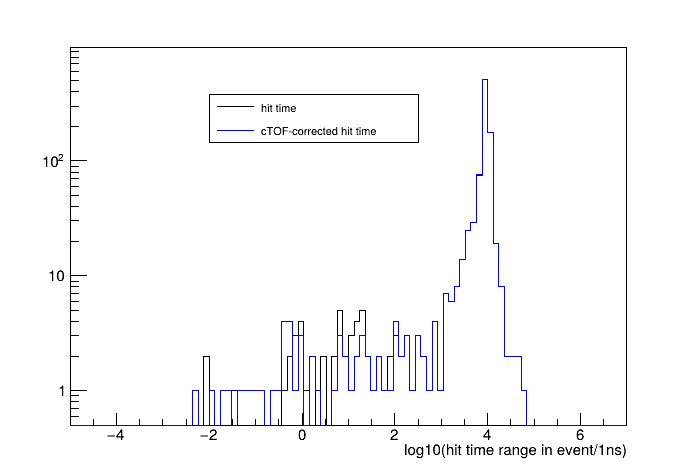

In [36]:
h_hits_log_dt.SetStats(False)
h_hits_log_dt_corr.SetStats(False)
h_hits_log_dt.SetLineColor(ROOT.kBlack)
h_hits_log_dt_corr.SetLineColor(ROOT.kBlue)

leg = ROOT.TLegend(0.3,0.7,0.6,0.8)
leg.AddEntry(h_hits_log_dt.GetPtr(), "hit time", "l")
leg.AddEntry(h_hits_log_dt_corr.GetPtr(), "cTOF-corrected hit time", "l")

c = ROOT.TCanvas()
h_hits_log_dt.Draw("H")
h_hits_log_dt_corr.Draw("HSAME")
c.SetLogy()
leg.Draw()
c.Draw()

In [37]:
def spill_hits(spl_id):
    h = df.Filter(f"spl_id=={spl_id}").Histo2D(("","",200,0,20000,100,0,100),"hit_t","evt_id")
    g = df.Filter(f"spl_id=={spl_id}").Graph("evt_t","evt_id")
    h.SetStats(False)
    c = ROOT.TCanvas()
    h.Draw("colz")
    g.Draw("SAME*")
    c.Draw()
    return h, g, c
# h, g, c = spill_hits(0)

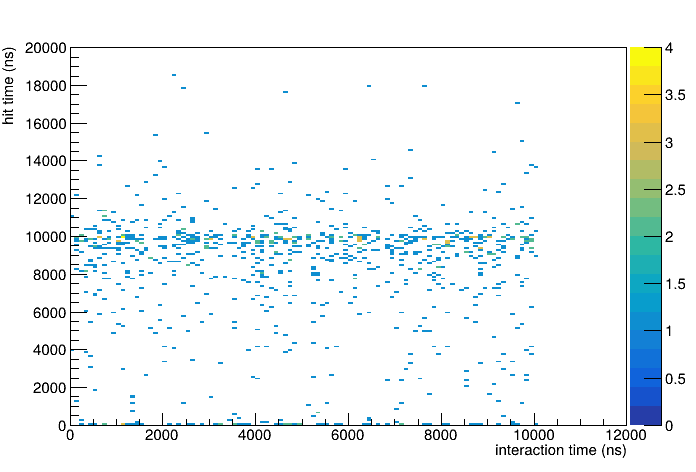

In [38]:
h_hits_t_vs_evt_t.SetStats(False)
c = ROOT.TCanvas()
h_hits_t_vs_evt_t.Draw("colz")
h_hits_t_vs_evt_t.GetYaxis().SetTitleOffset(1.55)
c.Draw()

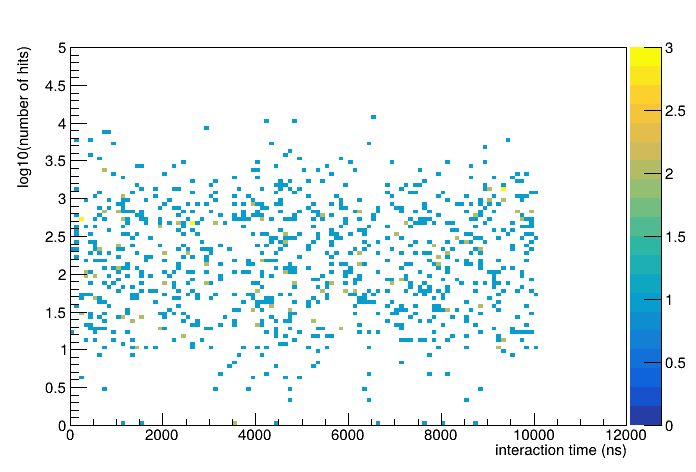

In [39]:
h_hits_logn_vs_evt_t.SetStats(False)
c = ROOT.TCanvas()
h_hits_logn_vs_evt_t.Draw("colz")
c.Draw()

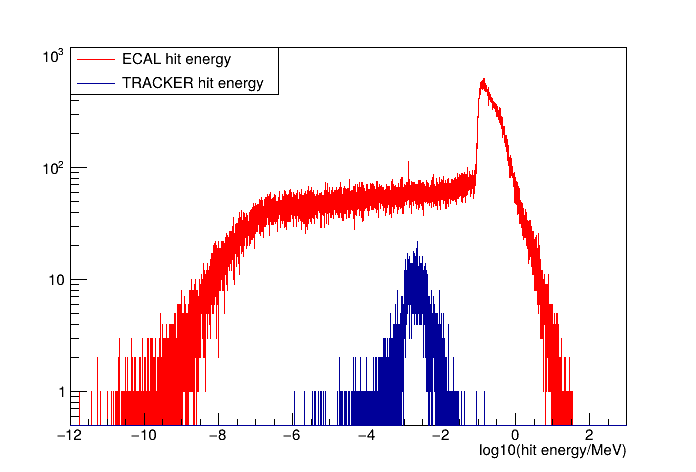

In [40]:
h_hit_ecal_log10_de.SetStats(False)
h_hit_trck_log10_de.SetStats(False)
h_hit_ecal_log10_de.SetLineColor(ROOT.kRed)

leg = ROOT.TLegend(0.1,0.8,0.4,0.9)
leg.AddEntry(h_hit_ecal_log10_de.GetPtr(), "ECAL hit energy", "l")
leg.AddEntry(h_hit_trck_log10_de.GetPtr(), "TRACKER hit energy", "l")

c = ROOT.TCanvas()
h_hit_ecal_log10_de.Draw()
h_hit_trck_log10_de.Draw("SAME")
c.SetLogy()
leg.Draw()
c.Draw()

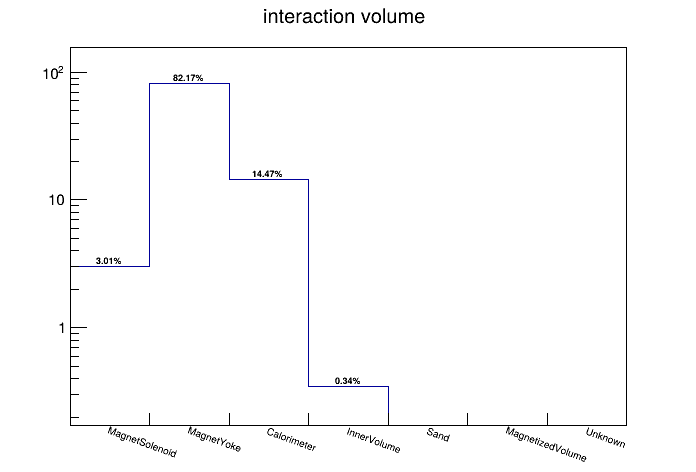

In [41]:
h_evt_geo_element_name = ROOT.TH1D("h_evt_geo_element_name","interaction volume",7,0,7)
h_evt_geo_element_name.SetStats(False)
for val in evt_geo_element_name_counts:
    h_evt_geo_element_name.SetBinContent(val[0]+1, val[2].GetValue()/evt_n.GetValue()*100)
    h_evt_geo_element_name.GetXaxis().SetBinLabel(val[0]+1,val[1])
c = ROOT.TCanvas()
h_evt_geo_element_name.Draw("HTEXT0")
c.SetLogy()
c.Draw()

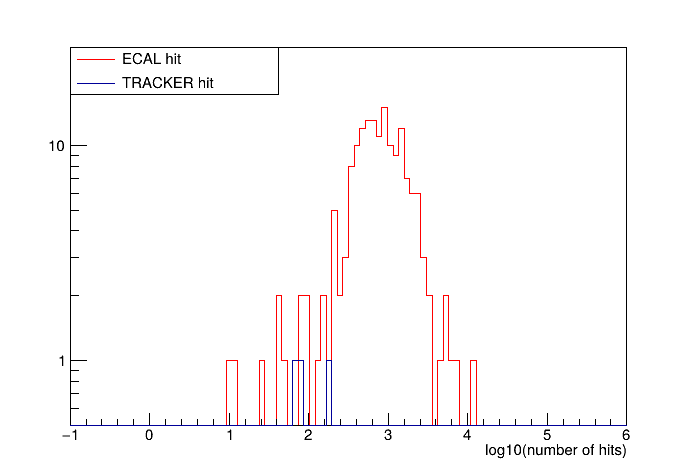

In [42]:
h_hits_ecal_log10_n.SetStats(False)
h_hits_trck_log10_n.SetStats(False)

h_hits_ecal_log10_n.SetLineColor(ROOT.kRed)

leg = ROOT.TLegend(0.1,0.8,0.4,0.9)
leg.AddEntry(h_hits_ecal_log10_n.GetPtr(), "ECAL hit", "l")
leg.AddEntry(h_hits_trck_log10_n.GetPtr(), "TRACKER hit", "l")

c = ROOT.TCanvas()
h_hits_ecal_log10_n.Draw("")
h_hits_trck_log10_n.Draw("SAME")
c.SetLogy()
leg.Draw()
c.Draw()

energy in ECAL    > 0: 99.4% of interactions in ECAL
energy in TRACKER > 0: 75.0% of interactions in internal volume

time window: 10 ns
ECAL    energy threshold:   5.000 MeV --> efficiency:  98.8%
TRACKER energy threshold:   0.005 MeV --> efficiency: 100.0%


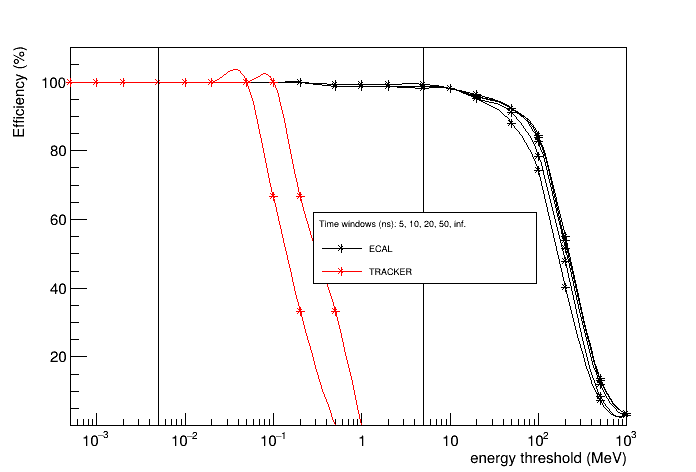

In [43]:
print(f"energy in ECAL    > 0: {evt_n_hits_ecal_sum_e_gt_0.GetValue()/evt_in_ecal_n.GetValue()*100.:4.1f}% of interactions in ECAL")
print(f"energy in TRACKER > 0: {evt_n_hits_trck_sum_e_gt_0.GetValue()/evt_in_invol_n.GetValue()*100.:4.1f}% of interactions in internal volume")

g_ecal_notw = ROOT.TGraph(len(ethrld))
g_trck_notw = ROOT.TGraph(len(ethrld))
g_ecal_wcut = {}
g_trck_wcut = {}

g_trck_notw.SetLineColor(ROOT.kRed)
g_trck_notw.SetMarkerColor(ROOT.kRed)

for ix, en in enumerate(evt_hits_ecal_sum_e_w_ecuts.keys()):
    g_ecal_notw.SetPoint(ix, en, evt_hits_ecal_sum_e_w_ecuts[en].GetValue()/evt_n_hits_ecal_sum_e_gt_0.GetValue()*100)
for ix, en in enumerate(evt_hits_trck_sum_e_w_ecuts.keys()):
    g_trck_notw.SetPoint(ix, en, evt_hits_trck_sum_e_w_ecuts[en].GetValue()/evt_n_hits_trck_sum_e_gt_0.GetValue()*100)

for tw in twndw:
    g_ecal_wcut[tw] = ROOT.TGraph(len(ethrld))
    for ix, en in enumerate(evt_hits_ecal_sum_e_w_tcuts_and_ecuts[tw].keys()):
        g_ecal_wcut[tw].SetPoint(ix, en, evt_hits_ecal_sum_e_w_tcuts_and_ecuts[tw][en].GetValue()/evt_n_hits_ecal_sum_e_gt_0.GetValue()*100)
    g_trck_wcut[tw] = ROOT.TGraph(len(ethrld))
    g_trck_wcut[tw].SetLineColor(ROOT.kRed)
    g_trck_wcut[tw].SetMarkerColor(ROOT.kRed)
    for ix, en in enumerate(evt_hits_trck_sum_e_w_tcuts_and_ecuts[tw].keys()):
        g_trck_wcut[tw].SetPoint(ix, en, evt_hits_trck_sum_e_w_tcuts_and_ecuts[tw][en].GetValue()/evt_n_hits_trck_sum_e_gt_0.GetValue()*100)

twdw = 10       # ns
eth_ecl = 5     # MeV
eth_trk = 0.005 # MeV
print(f"\ntime window: {twdw} ns")
print(f"ECAL    energy threshold: {eth_ecl:7.3f} MeV --> efficiency: {g_ecal_wcut[twdw].Eval(eth_ecl):5.1f}%")
print(f"TRACKER energy threshold: {eth_trk:7.3f} MeV --> efficiency: {g_trck_wcut[twdw].Eval(eth_trk):5.1f}%")

l1 = ROOT.TLine(eth_trk,0,eth_trk,110)
l2 = ROOT.TLine(eth_ecl,0,eth_ecl,110)

leg = ROOT.TLegend(0.45,0.4,0.77,0.55)
leg.SetHeader(f"Time windows (ns): {', '.join([str(item) for item in twndw])}, inf.")
leg.AddEntry(g_ecal_notw, "ECAL", "lp")
leg.AddEntry(g_trck_notw, "TRACKER", "lp")

c = ROOT.TCanvas()
h = c.DrawFrame(0.0005, 0.1, max(ethrld) + 1, 110.,"; energy threshold (MeV); Efficiency (%)")
h.GetXaxis().SetTitleOffset(1.3)
g_ecal_notw.Draw("C*")
g_trck_notw.Draw("C*")
for tw in twndw:
    g_ecal_wcut[tw].Draw("C*")
    g_trck_wcut[tw].Draw("C*")
c.SetLogx()
l1.Draw()
l2.Draw()
leg.Draw()
c.Draw()

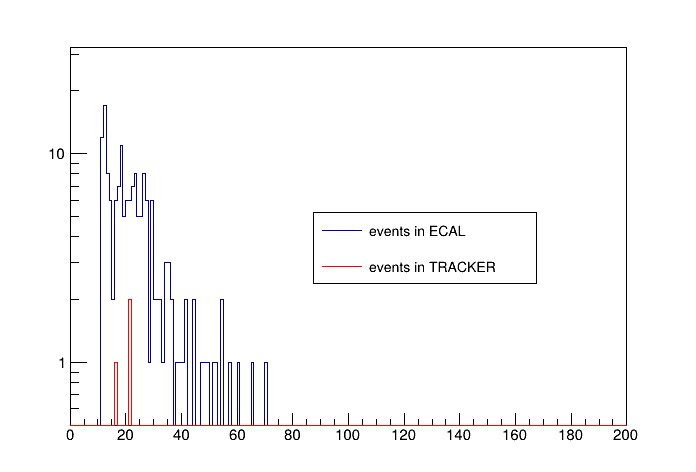

In [44]:
h_evt_hits_ecal_time_window_length.SetStats(False)
h_evt_hits_trck_time_window_length.SetStats(False)
h_evt_hits_trck_time_window_length.SetLineColor(ROOT.kRed)

leg = ROOT.TLegend(0.45,0.4,0.77,0.55)
leg.AddEntry(h_evt_hits_ecal_time_window_length.GetPtr(), "events in ECAL", "l")
leg.AddEntry(h_evt_hits_trck_time_window_length.GetPtr(), "events in TRACKER", "l")

c = ROOT.TCanvas()
h_evt_hits_ecal_time_window_length.Draw()
h_evt_hits_trck_time_window_length.Draw("SAME")
c.SetLogy()
leg.Draw()
c.Draw()

In [45]:
print(f"events in ECAL    with energy in ECAL   : {complete_events_in_ecal.GetValue():6d} out of {total_events_in_ecal.GetValue():6d} have all ECAL    hits in the time window => {100*complete_events_in_ecal.GetValue()/total_events_in_ecal.GetValue():3.1f}%") 
print(f"events in TRACKER with energy in TRACKER: {complete_events_in_invol.GetValue():6d} out of {total_events_in_invol.GetValue():6d} have all TRACKER hits in the time window => {100*complete_events_in_invol.GetValue()/total_events_in_invol.GetValue():3.1f}%") 

events in ECAL    with energy in ECAL   :    165 out of    167 have all ECAL    hits in the time window => 98.8%
events in TRACKER with energy in TRACKER:     48 out of     50 have all TRACKER hits in the time window => 96.0%
